<a href="https://colab.research.google.com/github/victor22-gif/victor-career-website/blob/main/Spam_detection_project/Spam_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Imports
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.pipeline import Pipeline
import pandas as pd
import matplotlib.pyplot as plt

# Define the SpamDetector class
class SpamDetector:
    def __init__(self, use_tfidf=True):
        if use_tfidf:
            self.vectorizer = TfidfVectorizer(stop_words="english")
        else:
            self.vectorizer = CountVectorizer(stop_words="english")
        self.pipeline = Pipeline([
            ('vectorizer', self.vectorizer),
            ('classifier', MultinomialNB())
        ])

    def fit(self, X, y):
        """Train the model."""
        self.pipeline.fit(X, y)

    def predict(self, X):
        """Predict the labels for a given set of emails."""
        return self.pipeline.predict(X)

    def predict_proba(self, X):
        """Predict probabilities for the given set of emails."""
        return self.pipeline.predict_proba(X)

    def evaluate_model(self, X, y):
        """Evaluate the model and return key metrics."""
        predictions = self.predict(X)
        probabilities = self.predict_proba(X)[:, 1]
        conf_matrix = confusion_matrix(y, predictions)
        fpr, tpr, _ = roc_curve(y, probabilities)
        roc_auc = auc(fpr, tpr)
        return {
            "confusion_matrix": conf_matrix,
            "roc_curve": (fpr, tpr, roc_auc)
        }

    def get_top_features(self, n=10):
        """Get the top features (words) for spam classification."""
        feature_names = self.vectorizer.get_feature_names_out()
        class_probabilities = self.pipeline.named_steps['classifier'].feature_log_prob_
        spam_class_index = 1  # Assuming class 1 represents spam
        top_indices = class_probabilities[spam_class_index].argsort()[-n:][::-1]
        return {feature_names[i]: class_probabilities[spam_class_index][i] for i in top_indices}

    def plot_roc_curve(self, fpr, tpr, roc_auc):
        """Plot the ROC curve."""
        plt.figure()
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Receiver Operating Characteristic')
        plt.legend(loc="lower right")
        plt.show()


Training the model...

Evaluating the model on the test set...

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       741
           1       1.00      0.40      0.57       159

    accuracy                           0.89       900
   macro avg       0.94      0.70      0.76       900
weighted avg       0.91      0.89      0.88       900


Confusion Matrix:
[[741   0]
 [ 95  64]]


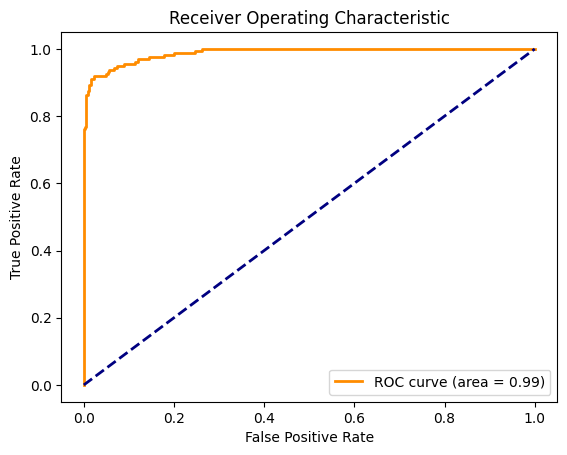


Top spam-indicating features:
number: -6.410
hyperlink: -6.807
click: -7.396
url: -7.470
free: -7.502
email: -7.815
money: -8.013
receive: -8.060
information: -8.082
mail: -8.210


In [4]:
# Main program
if __name__ == "__main__":
    # Load the dataset from a CSV file
    csv_file_path = "/content/spam_or_not_spam-1.csv" # Replace with the path to your CSV file
    data = pd.read_csv(csv_file_path)

    # Ensure columns are named correctly ('email' and 'label')
    if 'email' not in data.columns or 'label' not in data.columns:
        raise ValueError("The dataset must contain 'email' and 'label' columns.")

    # Drop rows with missing values in the 'email' or 'label' columns
    data = data.dropna(subset=['email', 'label'])

    # Convert the label column to integers if needed
    if data['label'].dtype != int:
        data['label'] = data['label'].astype(int)

    # Split the dataset into features (X) and labels (y)
    X = data['email']
    y = data['label']

    # Split into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    # Create and train the model
    detector = SpamDetector(use_tfidf=True)

    # Train the model
    print("\nTraining the model...")
    detector.fit(X_train, y_train)

    # Evaluate the model using the test set
    print("\nEvaluating the model on the test set...")
    evaluation = detector.evaluate_model(X_test, y_test)

    print("\nClassification Report:")
    print(classification_report(y_test, detector.predict(X_test)))

    print("\nConfusion Matrix:")
    print(evaluation['confusion_matrix'])

    # Plot ROC curve
    fpr, tpr, roc_auc = evaluation['roc_curve']
    detector.plot_roc_curve(fpr, tpr, roc_auc)

    # Get top spam-indicating features
    print("\nTop spam-indicating features:")
    top_features = detector.get_top_features(n=10)
    for feature, importance in top_features.items():
        print(f"{feature}: {importance:.3f}")